In [6]:
#Étape 1 — Télécharger les 3 actions en même temps
import yfinance as yf 
f=yf.download(['AAPL','MSFT','GOOGL'],start='2023-01-01',end='2024-12-31')
#Extraire uniquement les prix de cloture et calculer les rendements
C=f['Close']
Rd=C.pct_change().dropna()#.dropna pour supprimer la premiere ligne qui contient NAN
corr=Rd.corr()
print(Rd)
print(corr)

[*********************100%***********************]  3 of 3 completed

Ticker          AAPL     GOOGL      MSFT
Date                                    
2023-01-04  0.010314 -0.011670 -0.043743
2023-01-05 -0.010605 -0.021344 -0.029638
2023-01-06  0.036794  0.013225  0.011785
2023-01-09  0.004089  0.007786  0.009736
2023-01-10  0.004456  0.004545  0.007617
...              ...       ...       ...
2024-12-23  0.003065  0.016823 -0.003092
2024-12-24  0.011478  0.007604  0.009374
2024-12-26  0.003176 -0.002601 -0.002777
2024-12-27 -0.013242 -0.014520 -0.017302
2024-12-30 -0.013263 -0.007885 -0.013240

[500 rows x 3 columns]
Ticker      AAPL     GOOGL      MSFT
Ticker                              
AAPL    1.000000  0.439894  0.504956
GOOGL   0.439894  1.000000  0.535190
MSFT    0.504956  0.535190  1.000000


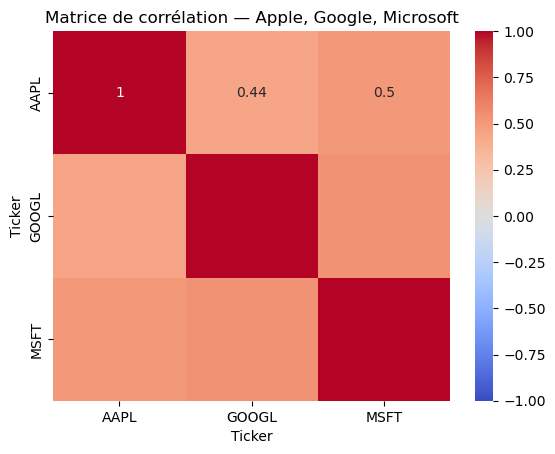

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1, vmax=1)
plt.title("Matrice de corrélation — Apple, Google, Microsoft")
plt.show()

In [5]:
import numpy as np 
Rapple=1.41
Rgoogle=1.38
cor=0.44
w1=0.5
w2=0.5
cov=cor*Rapple*Rgoogle
varp=w1**2*Rapple**2+w2**2*Rgoogle**2+2*w1*w2*cov
Rp=np.sqrt(varp)
print(cov)
print(varp)
print(Rp)

0.8561519999999999
1.4012009999999997
1.1837233629526789


In [17]:
w=np.array([0.5,0.5])
cov_matrix=Rd[['AAPL','GOOGL']].cov()
var_p = w @ cov_matrix.values @ w
R_p=np.sqrt(var_p)
print(cov_matrix)
print(var_p)
print(R_p)

Ticker      AAPL     GOOGL
Ticker                    
AAPL    0.000181  0.000109
GOOGL   0.000109  0.000339
0.00018458127283647676
0.01358606907226946


[*********************100%***********************]  2 of 2 completed

42
0.20781428525284681
0.002829161540325343
0.013613893466866887


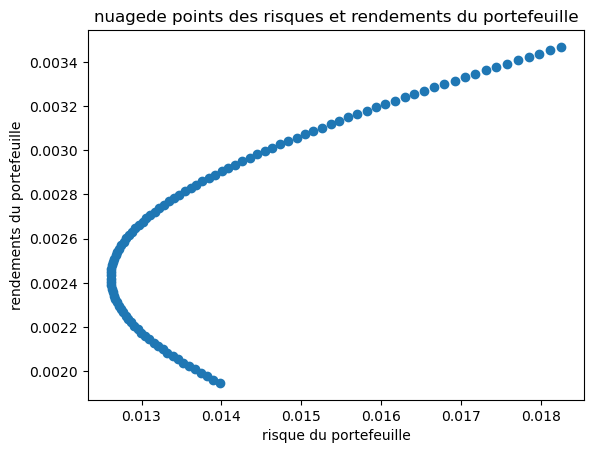

In [53]:
import numpy as np
import yfinance as yf
F=yf.download(['AAPL','GOOGL'],period='1y')
Rd=F['Close'].pct_change().dropna()
mu_apple=Rd['AAPL'].mean()
mu_google=Rd['GOOGL'].mean()
cov_matrix=Rd[['AAPL','GOOGL']].cov()
Rd_p=[]
ris_p=[]
for w1 in np.arange(0, 1.01, 0.01):
    w2=1-w1
    w=np.array([w1,w2])#generer toutes les combinaisons de poids
    rd_p=w1*mu_apple+w2*mu_google
    var=w @ cov_matrix.values @ w
    ris=np.sqrt(var)
    Rd_p.append(rd_p)
    ris_p.append(ris)
#calculer le risque et le rendements de chacune
sharpe_p=[]
for i in range(len(Rd_p)):
        sh=Rd_p[i]/ris_p[i]
        sharpe_p.append(sh)
sharpe_max=np.argmax(sharpe_p)#la position/indice du meilleur sharpe dans la liste sharpe_p cet indice est= le poids w1
print(sharpe_max)
print(sharpe_p[42])#meilleur sharpe
print(Rd_p[42])#le rendement de ce portefeuille
print(ris_p[42])#le risque de ce portefeuille
import matplotlib.pyplot as plt
plt.scatter(ris_p,Rd_p)
plt.title('nuagede points des risques et rendements du portefeuille')
plt.ylabel('rendements du portefeuille')
plt.xlabel('risque du portefeuille')
plt.show()



[*********************100%***********************]  2 of 2 completed


Poids optimal    : Apple 42% / Google 58%
Rendement optimal: 0.0028
Risque optimal   : 0.0136
Sharpe optimal   : 0.2078


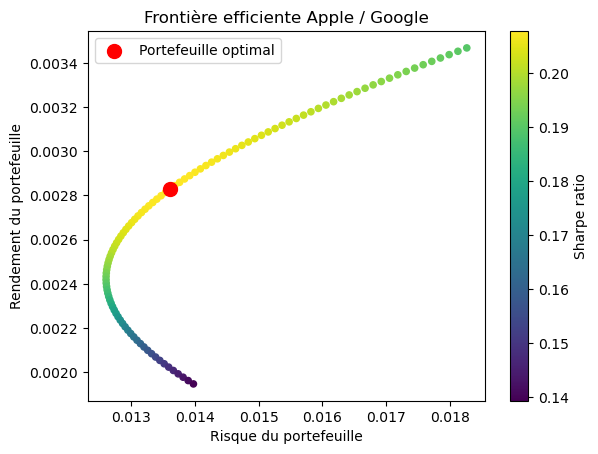

In [54]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# --- Données ---
F = yf.download(['AAPL', 'GOOGL'], period='1y')
Rd = F['Close'].pct_change().dropna()
mu_apple = Rd['AAPL'].mean()
mu_google = Rd['GOOGL'].mean()
cov_matrix = Rd[['AAPL', 'GOOGL']].cov()

# --- Combinaisons de poids ---
poids = np.arange(0, 1.01, 0.01)
Rd_p = []
ris_p = []
sharpe_p = []

for w1 in poids:
    w2 = 1 - w1
    w = np.array([w1, w2])
    
    rd_p = w1 * mu_apple + w2 * mu_google
    var = w @ cov_matrix.values @ w
    ris = np.sqrt(var)
    sh = rd_p / ris
    
    Rd_p.append(rd_p)
    ris_p.append(ris)
    sharpe_p.append(sh)

# --- Portefeuille optimal ---
meilleur_i = np.argmax(sharpe_p)
w1_opt = poids[meilleur_i]
w2_opt = 1 - w1_opt

print(f"Poids optimal    : Apple {w1_opt:.0%} / Google {w2_opt:.0%}")
print(f"Rendement optimal: {Rd_p[meilleur_i]:.4f}")
print(f"Risque optimal   : {ris_p[meilleur_i]:.4f}")
print(f"Sharpe optimal   : {sharpe_p[meilleur_i]:.4f}")

# --- Graphique ---
plt.scatter(ris_p, Rd_p, c=sharpe_p, cmap='viridis', s=20)
plt.colorbar(label='Sharpe ratio')
plt.scatter(ris_p[meilleur_i], Rd_p[meilleur_i], 
            color='red', s=100, label='Portefeuille optimal')
plt.title('Frontière efficiente Apple / Google')
plt.xlabel('Risque du portefeuille')
plt.ylabel('Rendement du portefeuille')
plt.legend()
plt.show()